In [1]:
import scipy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
hartree_to_ev = 27.2114
title_trans = {
    "sto3g":"QM9 HF@STO-3G",
    "qh9":"QM9 B3LYP@Def2SVP",
    "tm":"TMQM HF@STO-3G",
}

tot_molecules = {
    "sto3g" : 132070,
    "tm" : 34848,
    "qh9" : 130831,
}

data_10k = {
    "sto3g_occ":241297,
    "sto3g_virt":202215,
    "qh9_occ":209208,
    "qh9_virt":1177719,
    "tm_occ":946849,
    "tm_virt":841194
}

head_dir = "../model_eval/orbital_energy_predictions"
df = []
for d1 in ["sto3g","qh9","tm"]:
    for d2 in ["occ","virt"]:
        row = [f"{d1}_{d2}"]
        for t in [1000,10000,100000]:
            n = int(t/1000)
            true = np.load(f"{head_dir}/{n}k/{d1}_{d2}_val_true.npy")
            pred = np.load(f"{head_dir}/{n}k/{d1}_{d2}_val_pred.npy")
            row.append(np.abs(true-pred).mean())
        tot_10k = data_10k[f"{d1}_{d2}"]
        tot_all = tot_10k * tot_molecules[d1]/10000
        row.append(tot_10k)
        row.append(tot_all)
        df.append(row)
df = pd.DataFrame(df,columns=["type",1000,10000,100000,"tot_10k","tot_all"]).set_index("type")
df

,1000,10000,100000,tot_10k,tot_all
type,,,,,
sto3g_occ,0.017028,0.003892,0.000977,241297,3.186809e+06
sto3g_virt,0.016501,0.005300,0.001761,202215,2.670654e+06
qh9_occ,0.011212,0.003155,0.000696,209208,2.737089e+06
qh9_virt,0.100989,0.032681,0.011783,1177719,1.540822e+07
tm_occ,0.050644,0.018450,0.003431,946849,3.299579e+06
tm_virt,0.042211,0.017284,0.006311,841194,2.931393e+06


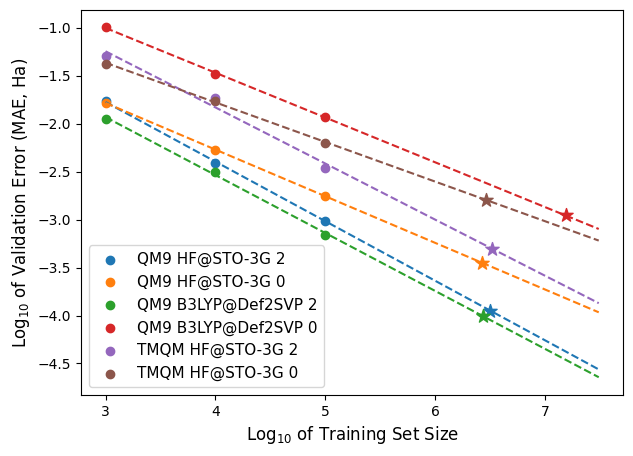

In [11]:
occ_trans = {"occ":2,"virt":0}
table = []
fig,ax = plt.subplots(figsize=(7,5))
for d1 in ["sto3g","qh9","tm"]:
    for d2 in ["occ","virt"]:
        label = title_trans[d1] + " " + str(occ_trans[d2])
        row = df.loc[f"{d1}_{d2}"]
        x = np.log10([1000,10000,100000])
        y = np.log10([row[1000],row[10000],row[100000]])
        from sklearn.linear_model import LinearRegression
        lr = LinearRegression()
        lr.fit(x[:,None],y[:,None])
        m,b = lr.coef_.squeeze(), lr.intercept_
        x0 = np.arange(3,7.5,0.01)
        y0 = m*x0 + b
        sc = plt.scatter(x,y,label=label)
        color = sc.get_facecolor()[0]
        x10k = np.log10(row["tot_all"])
        y10k = m*x10k+b
        plt.scatter(x10k,y10k,marker="*",s=100, color=color)
        extrap = (10**y10k)[0]
        lst = [title_trans[d1],occ_trans[d2],row[1000],row[10000],row[100000],extrap,float(m)]
        table.append(lst)
        plt.plot(x0,y0,linestyle="--")
        plt.legend(loc="lower left",fontsize=11)
plt.ylabel("Log$_{10}$ of Validation Error (MAE, Ha)",fontsize=12)
plt.xlabel("Log$_{10}$ of Training Set Size",fontsize=12)
plt.savefig("../figures/learning_curves.png",dpi=500)

In [19]:
occ_trans = {"occ":2,"virt":0}
table = []
for d1 in ["sto3g","qh9","tm"]:
    for d2 in ["occ","virt"]:
        label = title_trans[d1] + " " + str(occ_trans[d2])
        row = df.loc[f"{d1}_{d2}"]
        x = np.log10([1000,10000,100000])
        y = np.log10([row[1000],row[10000],row[100000]])
        from sklearn.linear_model import LinearRegression
        lr = LinearRegression()
        lr.fit(x[:,None],y[:,None])
        m,b = lr.coef_.squeeze(), lr.intercept_
        x0 = np.arange(3,7.5,0.01)
        y0 = m*x0 + b
        x10k = np.log10(row["tot_all"])
        y10k = m*x10k+b
        extrap = (10**y10k)[0]
        lst = [title_trans[d1],occ_trans[d2],row[1000],row[10000],row[100000],extrap,float(m)]
        table.append(lst)

table = pd.DataFrame(table,columns=["Data","Occ","10$^3$","10$^4$","10$^5$","Extrap.","$\\alpha_{10}$"])
for col in ["10$^3$","10$^4$","10$^5$","Extrap."]:
    table.loc[:,col] = np.round(table.loc[:,col]*1000,2)
table = np.round(table,2)
table

,Data,Occ,10$^3$,10$^4$,10$^5$,Extrap.,$\alpha_{10}$
0,QM9 HF@STO-3G,2,17.03,3.89,0.98,0.11,-0.62
1,QM9 HF@STO-3G,0,16.50,5.30,1.76,0.35,-0.49
2,QM9 B3LYP@Def2SVP,2,11.21,3.16,0.70,0.10,-0.60
3,QM9 B3LYP@Def2SVP,0,100.99,32.68,11.78,1.10,-0.47
4,TMQM HF@STO-3G,2,50.64,18.45,3.43,0.50,-0.58
5,TMQM HF@STO-3G,0,42.21,17.28,6.31,1.60,-0.41


In [18]:
print(table.to_latex(escape=False))

\begin{tabular}{llrrrrrr}
\toprule
{} &               Data &  Occ &  10$^3$ &  10$^4$ &  10$^5$ &  Extrap. &  $\alpha_{10}$ \\
\midrule
0 &      QM9 HF@STO-3G &    2 &    17.0 &     3.9 &     1.0 &      0.1 &          -0.62 \\
1 &      QM9 HF@STO-3G &    0 &    16.5 &     5.3 &     1.8 &      0.4 &          -0.49 \\
2 &  QM9 B3LYP@Def2SVP &    2 &    11.2 &     3.2 &     0.7 &      0.1 &          -0.60 \\
3 &  QM9 B3LYP@Def2SVP &    0 &   101.0 &    32.7 &    11.8 &      1.1 &          -0.47 \\
4 &     TMQM HF@STO-3G &    2 &    50.6 &    18.5 &     3.4 &      0.5 &          -0.58 \\
5 &     TMQM HF@STO-3G &    0 &    42.2 &    17.3 &     6.3 &      1.6 &          -0.41 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_2598853/1166261648.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(table.to_latex(escape=False))
